In [1]:
import pandas as pd

In [2]:
historical=pd.read_csv("datasets/historical_data.csv")
fear=pd.read_csv("datasets/fear_greed_index.csv")


In [3]:
print(historical.head())
print(fear.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [6]:
fear['date']=pd.to_datetime(fear['date'],dayfirst=True).dt.date
historical['date']=pd.to_datetime(historical['Timestamp IST'],dayfirst=True).dt.date

In [8]:
print(historical[['Timestamp IST','date']].head())
print(fear[['date','date']].head())

      Timestamp IST        date
0  02-12-2024 22:50  2024-12-02
1  02-12-2024 22:50  2024-12-02
2  02-12-2024 22:50  2024-12-02
3  02-12-2024 22:50  2024-12-02
4  02-12-2024 22:50  2024-12-02
         date        date
0  2018-02-01  2018-02-01
1  2018-02-02  2018-02-02
2  2018-02-03  2018-02-03
3  2018-02-04  2018-02-04
4  2018-02-05  2018-02-05


Merging on basis of date which we have converted into same format

In [9]:
merged=pd.merge(historical,fear,on='date',how='inner')

In [10]:
print(merged.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

## Now we would start with our *analysis* for the datasets ## 

#### 1. AVERAGE PROFIT

##### One of the direct is taking the **Average** of both the classification groups *Fear* and *Greed*. This helps us to see the performance of how people act in these emotions.

In [14]:
print(merged.groupby('classification')['Closed PnL'].mean())

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


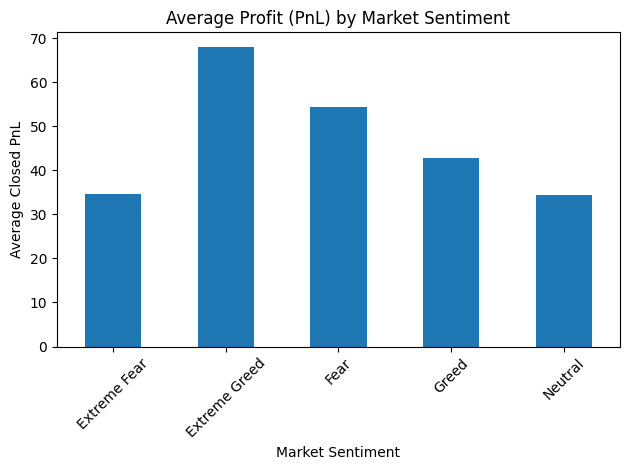

In [17]:
import matplotlib.pyplot as plt

avg_pnl = merged.groupby('classification')['Closed PnL'].mean()

plt.figure()
avg_pnl.plot(kind='bar')
plt.title("Average Profit (PnL) by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### So form the analysis of Closed PnL (profit or loss from a trade is completed) we can say trader profitability is highest during extreme greed showcasing strong performance. Fear also shows relatively high profitability. But moderate greed does not yeild good result

#### 2. On Basis of only **Profit** 

In [20]:
merged['win'] = merged['Closed PnL'] > 0
print(merged.groupby('classification')['win'].mean())

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


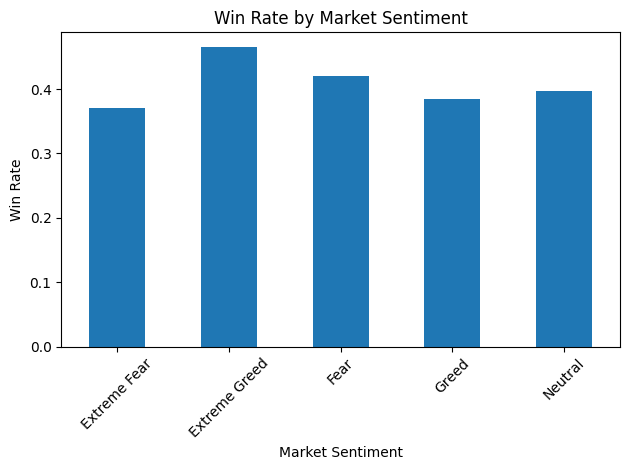

In [21]:
win_rate = merged.groupby('classification')['win'].mean()
plt.figure()
win_rate.plot(kind='bar')
plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### On the basis of Profit or winning we can see that during extreme greed there is the most profit. So in both the profit and loss extreme greed is said to be profitable

#### 3. On basis of Leverage

##### Leverage is used to show aggressive trading or cautious trading

In [23]:
print(merged.groupby('classification')['Size USD'].mean())

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


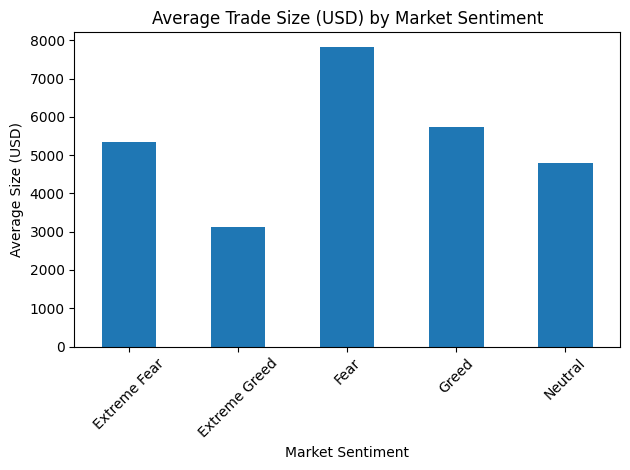

In [25]:
lev = merged.groupby('classification')['Size USD'].mean()
plt.figure()
lev.plot(kind='bar')
plt.title("Average Trade Size (USD) by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Size (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### In this we can see that traders are taking maximum risk in fear. While during extreme greed they are taking least risk.

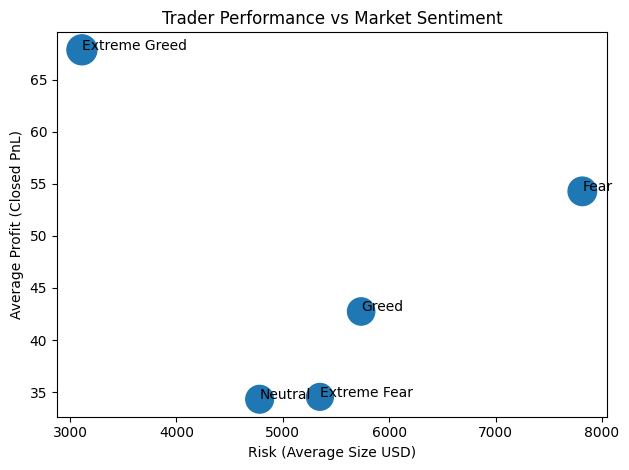

In [28]:
summary = merged.groupby('classification').agg({
    'Closed PnL': 'mean',
    'win': 'mean',
    'Size USD': 'mean'
}).reset_index()
plt.figure()
plt.scatter(
    summary['Size USD'], 
    summary['Closed PnL'], 
    s=summary['win'] * 1000,  # bubble size
)
for i in range(len(summary)):
    plt.text(
        summary['Size USD'][i], 
        summary['Closed PnL'][i], 
        summary['classification'][i]
    )
plt.xlabel("Risk (Average Size USD)")
plt.ylabel("Average Profit (Closed PnL)")
plt.title("Trader Performance vs Market Sentiment")
plt.tight_layout()
plt.show()

##### So the bubble graph shows each setiment with each bubble.
##### *TOP RIGHT->* High profit + High Risk
##### *BOTTOM RIGHT->* High Risk + Low Profit
##### *TOP LEFT->* Low Risk + High Profit(Best)
##### So from the datasets given we can say that in extreme greed brings the most profit with low risk

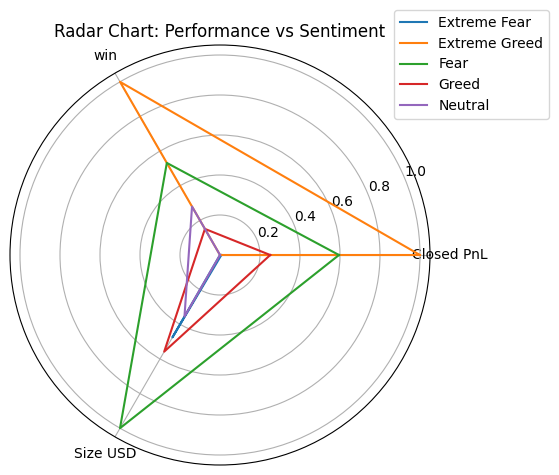

In [32]:
import numpy as np
merged['Closed PnL'] = pd.to_numeric(merged['Closed PnL'], errors='coerce')
merged['Size USD'] = pd.to_numeric(merged['Size USD'], errors='coerce')
merged['win'] = merged['win'].astype(float)
summary = merged.groupby('classification').agg({
    'Closed PnL': 'mean',
    'win': 'mean',
    'Size USD': 'mean'
})
categories = ['Closed PnL', 'win', 'Size USD']
labels = summary.index.tolist()
normalized = (summary - summary.min()) / (summary.max() - summary.min())
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))
plt.figure()
ax = plt.subplot(111, polar=True)

for i, label in enumerate(labels):
    values = normalized.iloc[i].values
    values = np.concatenate((values, [values[0]]))
    
    ax.plot(angles, values, label=label)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title("Radar Chart: Performance vs Sentiment")
plt.legend(bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

##### This radar chart also shows the balance between *Profit , Win Rate , Risk*